<a href="https://colab.research.google.com/github/nushuhu51-ux/TENSORFLOW-FULL-COURSE-FOR-DEEP-LEARNING/blob/main/01_neural_network_regression_with_tensorflow_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Regression with Neural Networks in TensorFlowiy.

There many definitions for a regression problems in our case, we're going to simplify:predicting a numerical variable based on some other combination of variable's, even shorter..predicting a number.

In [40]:
# import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.20.0


### Creating data to view and fit

(<matplotlib.collections.PathCollection at 0x7afefb770e60>,)

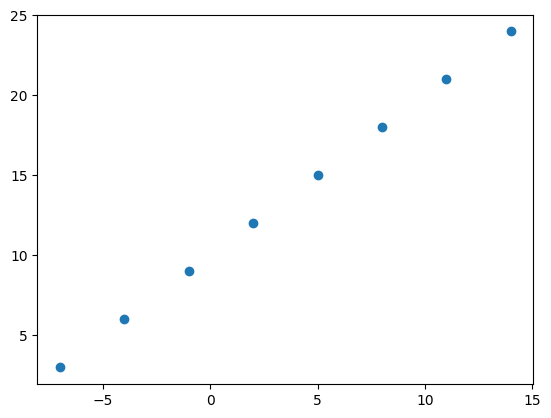

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# create features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0, ])

# create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# visualize
plt.scatter(x, y),

In [42]:
y == x+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

### Input and output shapes

In [43]:
# create a demo tensor for our housing price prediction problems
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])

house_info, house_price


(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [44]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

In [45]:
x[0].ndim

0

In [46]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [47]:
# Turn our Numpy array into tensors
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
x, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [48]:
input_shape = x[0].shape
output_shape = y[0].shape

input_shape, output_shape

(TensorShape([]), TensorShape([]))

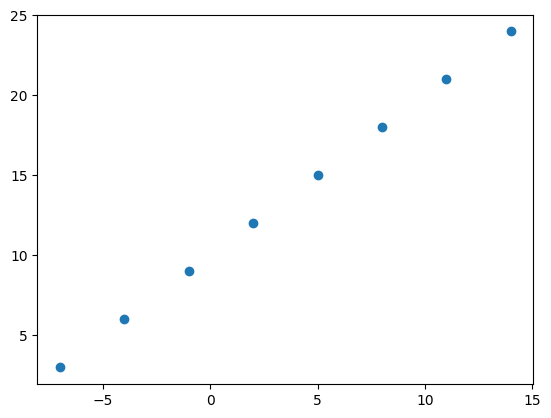

In [49]:
plt.scatter(x, y)

### steps in modelling with TensorFlow

1. Creating a model - define the input and output layer, as well as the hidden layers of a deep learing model.
2. Compiling a model - define the loss function (in other words, the function which tells our model how wrong it is) and the optimizer(tells our model how to improve the patterns its learning) and evaluation metrics(what we can use to interpret the performance of our model).
3. Fitting a model-letting the model try to find patterns between x & y (features and labels)

In [50]:
x = tf.reshape(x, (-1, 1))

In [51]:
# 1. Create a model (specified to your problem)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model
model.fit(x, y, epochs=5)

# 4. Evaluate the model
model.evaluate(x, y)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - loss: 7.7555 - mae: 7.7555
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.6230 - mae: 7.6230
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.4905 - mae: 7.4905
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 7.4775 - mae: 7.4775
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 7.4719 - mae: 7.4719
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - loss: 7.4662 - mae: 7.4662


[7.466249942779541, 7.466249942779541]

In [52]:
# check out x and y
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [53]:
# try and make a prediction using our model
y_pred = model.predict(tf.constant([[17.0]]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


array([[29.731821]], dtype=float32)

In [54]:
y_pred+11

array([[40.73182]], dtype=float32)

### Improving our model

we can improve our model, by altering the steps we took to create a model.

1. **Creating a model** - define the input and output layer, as well as the hidden layers of a deep learing model.
2. **Compiling a model** - here we night fit change the optimization function or perhaps the **learning rate** of the optimization function
3. **Fitting a model** - here we might fit a model for more (give the model more examples to learn from)

In [55]:
# let's rebuild our model

# 1. create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# 2. compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochasitc dradiant descent
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step - loss: 19.0652 - mae: 19.0652
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 18.7840 - mae: 18.7840
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 18.5027 - mae: 18.5027
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 18.2215 - mae: 18.2215
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 17.9402 - mae: 17.9402
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 17.6590 - mae: 17.6590
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 17.3777 - mae: 17.3777
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 17.0965 - mae: 17.0965
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 16.8152 - mae: 16.8152
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 16.5340 - mae: 16.5340
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 16.2527 - mae: 16.2527
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 15.9715 - mae: 15.9715
Epoch 13/100
1/1 ━━━━━

In [56]:
# Remind ourselfs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [57]:
# Let's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


array([[29.23572]], dtype=float32)

In [58]:
# Let's see if we can make another to improve our model

# 1. create the model(this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - loss: 12.6761 - mae: 12.6761
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.0317 - mae: 12.0317
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.3751 - mae: 11.3751
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.7056 - mae: 10.7056
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.0312 - mae: 10.0312
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9.3339 - mae: 9.3339
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.6021 - mae: 8.6021
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.8389 - mae: 7.8389
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.0275 - mae: 7.0275
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 6.1736 - mae: 6.1736
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5.2547 - mae: 5.2547
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4.4213 - mae: 4.4213
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [59]:
# let's remind ourselvs of the data
x, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [60]:
# let's try to make a prediction
model.predict(np.array([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


array([[32.20177]], dtype=float32)

### Evaluating a Model

In practice , a typical workflow you will go throgh when building neural networks is:

'''
Build a model -> fit it -> evaluate it -> tweak a model -> fit is -> evaluate is -> tweak a model -> ...

when it comes to evaluation... there are 3 words you should memorize:

> "Visualize, visualize, visualize"
 it is good to visualize:

 * The data- what data are we working with? what does it looks like?
 * the model itself-what does our model looks like?
 * the training of a model-how does a model perform while it learns?
 * the predictions of the model-how to the predictions of a model line up against of the ground truth?

In [61]:
# make a bigger dataset
x = tf.range(-100, 100, 4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [62]:
# make labels for the dataset
y = x+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

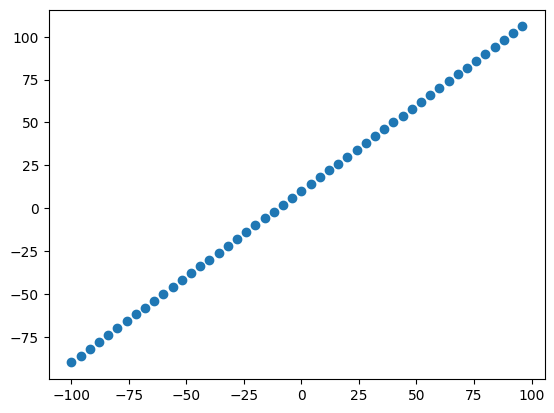

In [63]:
# visualize the data
import matplotlib.pyplot as plt
plt.scatter(x, y)

### The 3 sets...

* **training set**- the model learns from this data, which is typically 70-80% of the total data you have available.
* **validation set**- the model gets tuned on this data, which is typically 10-15% of the data available.
* **test set** - the model gets evaluated on this data to  test what is has learned, this set is typically 10-15% of the total data available.

In [64]:
# check the length of how many samples we have
len(x)

50

In [65]:
# split the data into train and test sets
x_train = x[:40]
y_train = y[:40]


x_test = x[40:]
y_test = y[40:]

len(x_train), len(x_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualizing the data

Now we've got our data in training and testing sets..let's as visualize is again!

(<matplotlib.legend.Legend at 0x7afefb2b9f70>,)

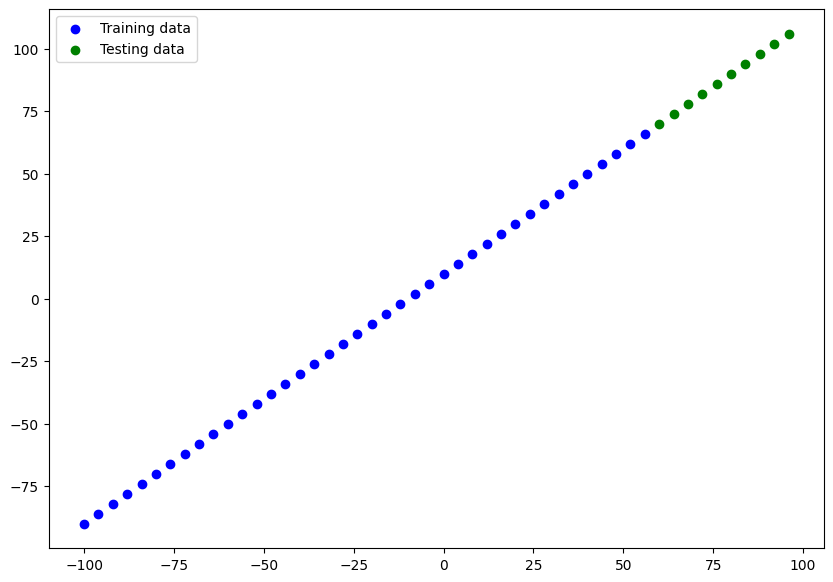

In [66]:
plt.figure(figsize=(10, 7))
# plot training the data in blue
plt.scatter(x_train, y_train, c="b", label="Training data")
# plot test data in green
plt.scatter(x_test, y_test, c="g", label="Testing data")
# show a legend
plt.legend(),

In [97]:
# Let's have a look at how to build a neural network for our data
tf.random.set_seed(42)
# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="Model_one")
# 2. compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. fit the model
model.fit(x_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 41.8454 - mae: 41.8454
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.4732 - mae: 10.4732
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 15.7171 - mae: 15.7171
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.7599 - mae: 11.7599
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 15.0794 - mae: 15.0794
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.8053 - mae: 15.8053
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 12.4783 - mae: 12.4783
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.0997 - mae: 15.0997
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.6522 - mae: 11.6522
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.0538 - mae: 15.0538
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.6313 - mae: 11.6313
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.0385 - mae: 15.0385
Epoch 13/100
2/2 ━━━━━━━

### Visualizing the model

In [99]:
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

* Total params - total number of parameters in the model.
* Trainable params - these are the parameters the model can update as it trains.
* Non-trainable params- these parameters are not updated during training.

In [100]:
# Let's fit our model to the training data
model.fit(x_train, y_train, epochs=100, verbose=0)

In [101]:
# Get a summary of our model
model.summary()

Model: "Model_one"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

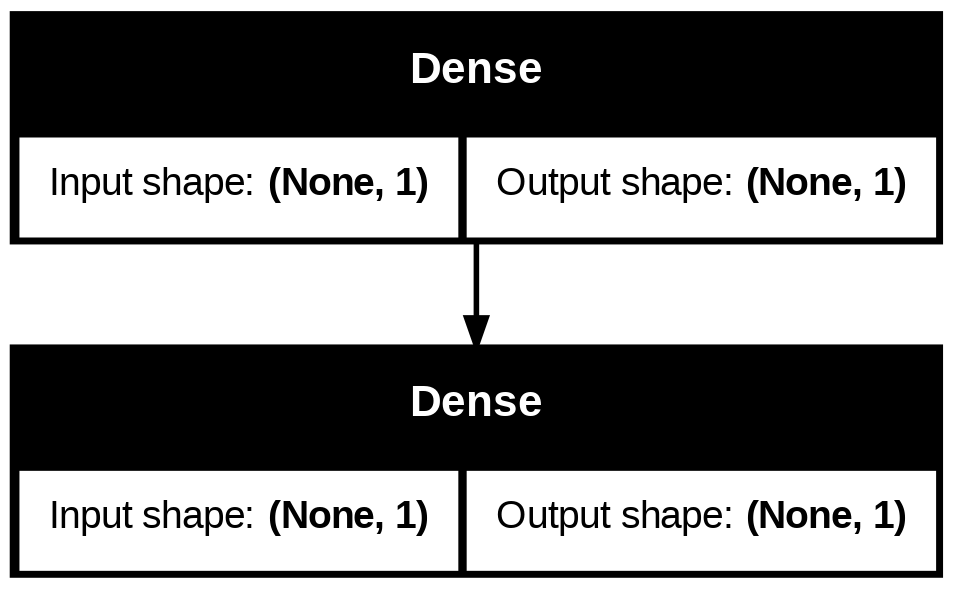

In [102]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True)

### Visualizing our model's predictions

In [ ]:
#